# Памперсы или пиво? Практический проект по созданию рекомендательной системы.

Настало время поработать с данными самой большой и самой дорогой компании, занимающейся, похоже, уже всем на свете: от продажи всего и вся, до настройки облачных инфраструктур и создания роботов. Конечно же это компания Джеффа могу-купить-весь-мир Безоса - Amazon.

* Выберите любой понравившийся вам набор данных по ссылке https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/, стоит обратить внимание на раздел "Small" subsets for experimentation, где представлены не самые большие датасеты (чтобы и в память поместился, и считался недолго).
* Проведите базовый EDA - распределения рейтингов, количество уникальных товаров и т.д.
* Сделайте разбиение данных на train и test методом leave-one-out.
* На основании вашего датасета постройте 2-3 рекомендательных модели, можно включить простой бейзлайн типа модели, рекомендующей самые популярные товары.
* Оцените качество полученных рекомендаций по метрикам HR@10, MRR@10, NDCG@10, coverage.
* Сделайте выводы о качестве моделей.

In [35]:
!pip install implicit

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

import scipy.sparse as sparse
import implicit

Выбран датасет Software_5

In [37]:
dataset_feedback = pd.read_json("HW10(lesson37)_data.json", orient="records", lines=True)

# Разведочный анализ данных

In [38]:
dataset_feedback.head(3).T

,0,1,2
overall,4,4,5
verified,False,False,False
reviewTime,"10 20, 2010","10 18, 2010","10 16, 2010"
reviewerID,A38NELQT98S4H8,A3QJU4FEN8PQSZ,ACJT8MUC0LRF0
asin,0321719816,0321719816,0321719816
style,{'Format:': ' DVD-ROM'},{'Format:': ' DVD-ROM'},{'Format:': ' DVD-ROM'}
reviewerName,WB Halper,Grimmy,D. Fowler
reviewText,I've been using Dreamweaver (and it's predeces...,"The demo is done with the PC version, with ref...",If you've been wanting to learn how to create ...
summary,A solid overview of Dreamweaver CS5,A good value,This is excellent software for those who want ...
unixReviewTime,1287532800,1287360000,1287187200


Описание столбцов:
* overall           - оценка продукта (rating of the product)
* verified          - отзыв (или рецензент?) подтвержден (---)
* reviewTime        - дата оценки (time of the review (raw))
* reviewerID        - внутренний код рецензента (ID of the reviewer, e.g. A2SUAM1J3GNN3B)
* asin              - внутренний код товара (ID of the product, e.g. 0000013714)
* style             - формат получения продукта (a disctionary of the product metadata, e.g., "Format" is "Hardcover")
* reviewerName      - имя рецензента (name of the reviewer)
* reviewText        - развернутый отзыв (text of the review)
* summary           - краткий отзыв (summary of the review)
* unixReviewTime    - еще один формат времени оценки (time of the review (unix time))
* vote              - общее число отзывов рецензента (helpful votes of the review)
* image             - фото товара от пользователя (images that users post after they have received the product)

In [39]:
USER_COL_ORIGINAL = "reviewerID"
USER_COL_INTERNAL = "userID"
ITEM_COL_ORIGINAL = "asin"
ITEM_COL_INTERNAL = "itemID"
RATING_COL_ORIGINAL = "overall"
TIMESTAMP_COL_ORIGINAL = "unixReviewTime"

PREDICTION_POPULAR_COL = "predPopular"
PREDICTION_USER_COL = "predKNNUser"
PREDICTION_ITEM_COL = "predKNNItem"
PREDICTION_ALS_COL = "predALS"

PREDICTION_NUM = 10

In [40]:
def filter_duplicates(dataset):
    return dataset.drop_duplicates(subset=[USER_COL_ORIGINAL, ITEM_COL_ORIGINAL], keep="last")

In [41]:
# сразу удаляем дубликаты, оставляя последний по времени
dataset_feedback = filter_duplicates(dataset_feedback)

In [42]:
dataset_feedback.isnull().sum()

overall               0
verified              0
reviewTime            0
reviewerID            0
asin                  0
style              5098
reviewerName          9
reviewText            1
summary               5
unixReviewTime        0
vote               8348
image             11817
dtype: int64

в критичных для нас полях (оценка, ID товара и рецензента, время оценки) пропусков нет. это приятно.

In [43]:
dataset_feedback.info()

<class 'pandas.DataFrame'>
Index: 11884 entries, 0 to 12804
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   overall         11884 non-null  int64 
 1   verified        11884 non-null  bool  
 2   reviewTime      11884 non-null  str   
 3   reviewerID      11884 non-null  str   
 4   asin            11884 non-null  str   
 5   style           6786 non-null   object
 6   reviewerName    11875 non-null  str   
 7   reviewText      11883 non-null  str   
 8   summary         11879 non-null  str   
 9   unixReviewTime  11884 non-null  int64 
 10  vote            3536 non-null   str   
 11  image           67 non-null     object
dtypes: bool(1), int64(2), object(2), str(7)
memory usage: 1.1+ MB


оценка числовая, преобразовывать не требуется, ID строковые, но нам все-равно их маскировать внутренним счетчиком.

для сортировки по времени можно использовать unixReviewTime, он тоже числовой

In [44]:
for col in [RATING_COL_ORIGINAL, USER_COL_ORIGINAL, ITEM_COL_ORIGINAL, ]:
    print(f"{col}: {dataset_feedback[col].unique().shape[0]}")

overall: 5
reviewerID: 1826
asin: 802


1826 рецензентов оценили 802 товара по 5ти бальной шкале

In [45]:
dataset_feedback.shape[0] / (dataset_feedback[USER_COL_ORIGINAL].unique().shape[0] * dataset_feedback[ITEM_COL_ORIGINAL].unique().shape[0])

0.008114980893877027

имеем менее процента заполненных данных. в целом не худший вариант (для явного фидбэка вообще хорошо)

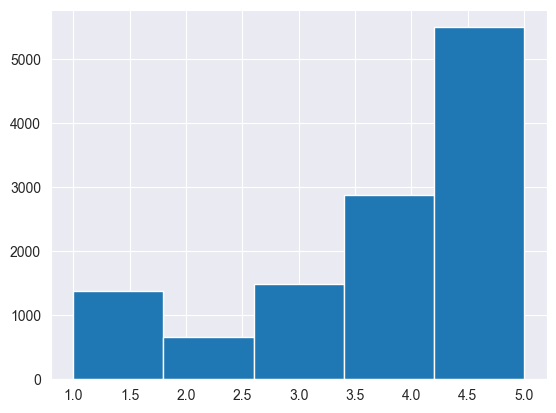

In [46]:
dataset_feedback[RATING_COL_ORIGINAL].hist(bins=5);

высоких оценок больше, что ожидаемо - мы не любим взаимодействовать с чем-то неприятным и не все готовы ставить низкую оценку (проще вообще ничего не ставить)

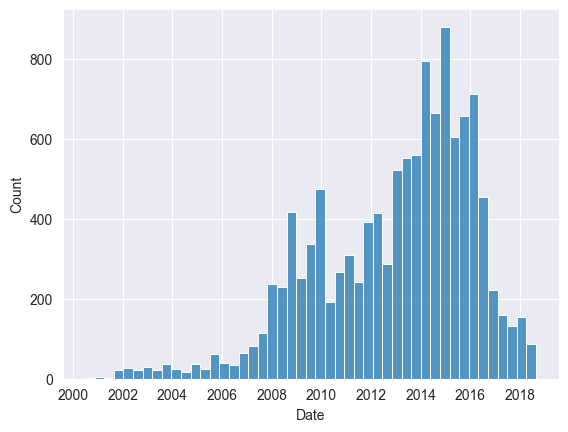

In [47]:
dataset_view_date = pd.DataFrame({
    "Date": pd.to_datetime(dataset_feedback["reviewTime"], format="%m %d, %Y")
})
sns.histplot(data=dataset_view_date, x="Date")
plt.show()

статистика аж с 2000 года, но основная масса отзывов в 2014-2017 гг.

в принципе, можно даже откинуть статистику до 2008 года, во-первых, ее немного, во-вторых, ее актуальность сомнительна (10 лет все-таки)

неприятно, что статистика сильно просела в конце выгрузки, т.е. что бы набрать 20% пришлось бы отступать больше

<Axes: >

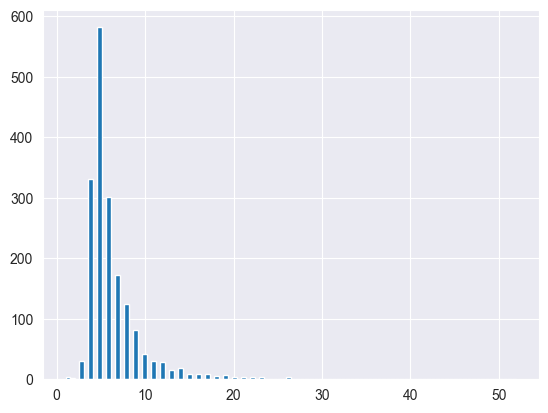

In [48]:
dataset_feedback.groupby(USER_COL_ORIGINAL)[ITEM_COL_ORIGINAL].count().hist(bins=100)

в основном один пользователь оставляет 3-5 (очень редко больше 15) отзывов

пользователей оставивших менее 3х оценок немного, поэтому их будем считать холодными и отфильтруем

<Axes: >

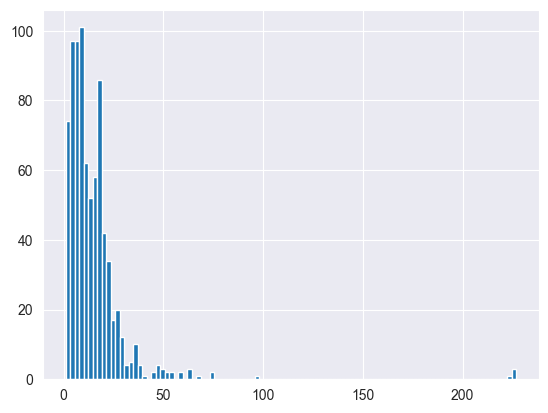

In [49]:
dataset_feedback.groupby(ITEM_COL_ORIGINAL)[USER_COL_ORIGINAL].count().hist(bins=100)

большинство товаров оценили не так много пользователей, поэтому фильтровать по количеству оценок не получится (в крайнем случае можно отфильтровать с 1 оценкой)

есть несколько крайне популярных товаров (оценили более 200 из 1826 рецензентов)

# Построение рекомендательной системы

## Подготовка данных

In [50]:
def filter_data(dataset, user_vote_min = 1, item_rating_min = 1):
    # фильтруем пользователей по количеству оценок
    user_vote_counts = dataset.groupby(USER_COL_ORIGINAL)[ITEM_COL_ORIGINAL].count()
    active_users = user_vote_counts[user_vote_counts >= user_vote_min]
    dataset = dataset[dataset[USER_COL_ORIGINAL].isin(active_users.index)]

    # фильтруем товары по количеству оценок
    item_rating_counts = dataset.groupby(ITEM_COL_ORIGINAL)[USER_COL_ORIGINAL].count()
    popular_items = item_rating_counts[item_rating_counts >= item_rating_min]
    dataset = dataset[dataset[ITEM_COL_ORIGINAL].isin(popular_items.index)]
    return dataset

In [51]:
# пользователей оценивших менее 3х продуктов считаем холодными и отфильтровываем
dataset_feedback = filter_data(dataset_feedback, user_vote_min=2)

In [52]:
def make_internal_dict(dataset):
    dataset[USER_COL_INTERNAL], user_index = pd.factorize(dataset[USER_COL_ORIGINAL])
    user_internal_dict = dict(enumerate(user_index))
    # user_original_dict = {original: internal for internal, original in user_internal_dict.items()}

    dataset[ITEM_COL_INTERNAL], item_index = pd.factorize(dataset[ITEM_COL_ORIGINAL])
    item_internal_dict = dict(enumerate(item_index))
    return user_internal_dict, item_internal_dict

In [53]:
# маскируем ID
user_internal_dict, item_internal_dict = make_internal_dict(dataset_feedback)

In [54]:
def train_test_split(dataset, user_col, time_col):
    full_history = dataset.sort_values([user_col, time_col]).groupby(user_col)
    test = full_history.tail(1)
    train = full_history.head(-1)
    return train, test

In [55]:
train, test = train_test_split(dataset_feedback, USER_COL_INTERNAL, RATING_COL_ORIGINAL)

# в тесте оставляем только высокие оценки (все-таки продукт на 3ку мы рекомендовать не стремимся)
test = test[test[RATING_COL_ORIGINAL] >= 4]
# train по методу отбора уже имеет историю в test, поэтому дополнительно отсеивать не требуется

In [56]:
cols = train[ITEM_COL_INTERNAL].astype("category").cat.codes
print(f"{cols.max()} vs {train[ITEM_COL_INTERNAL].max()}")

790 vs 799


In [57]:
results_pred = test.copy()
results_metrics = pd.DataFrame()

## Расчет оценок

In [58]:
def mrr(df: pd.DataFrame, pred_col, test_col) -> float:
    mrr_values = []
    for _, row in df.iterrows():
      try:
        user_mrr = 1 / (row[pred_col].index(row[test_col]) + 1)
      except ValueError:
        user_mrr = 0
      mrr_values.append(user_mrr)
    return np.mean(mrr_values)

def hr(df: pd.DataFrame, pred_col, test_col) -> float:
    hr_values = []
    for _, row in df.iterrows():
      hr_values.append(int(row[test_col] in row[pred_col]))
    return np.mean(hr_values)

def ndcg(df: pd.DataFrame, pred_col, test_col) -> float:
    ndcg_values = []
    for _, row in df.iterrows():
      try:
        user_ndcg = 1 / np.log2(row[pred_col].index(row[test_col]) + 2)
      except ValueError:
        user_ndcg = 0
      ndcg_values.append(user_ndcg)
    return np.mean(ndcg_values)

def coverage(train_df: pd.DataFrame, pred_df: pd.DataFrame, item_col, pred_col) -> float:
    total_items_num = train_df[item_col].nunique()
    pred_items_num = len(set.union(*pred_df[pred_col].map(lambda x: set(x))))
    return pred_items_num / total_items_num

def calculate_metrics(train_df: pd.DataFrame, pred_df: pd.DataFrame, item_col, pred_col, test_col):
    results = {
        "mrr" : mrr(pred_df, pred_col, test_col),
        "hr" : hr(pred_df, pred_col, test_col),
        "ndcg" : ndcg(pred_df, pred_col, test_col),
        "coverage" : coverage(train_df, pred_df, item_col, pred_col),
    }
    for metrics, value in results.items():
        print(f"{metrics} = {value}")
    return results

## Популярные с высоким рейтингом

In [59]:
popular_items_lst = Counter(train[train[RATING_COL_ORIGINAL] == 5][ITEM_COL_INTERNAL])
popular_items_lst = [*popular_items_lst.items()]
popular_items_lst.sort(key=lambda x: x[1], reverse=True)

predictions = []
for i, item in results_pred.iterrows():
  has_seen = list(train[train[USER_COL_INTERNAL] == item[USER_COL_INTERNAL]][[ITEM_COL_INTERNAL]])
  cur_preds = [k for k, v in popular_items_lst if not k in has_seen][:PREDICTION_NUM]
  predictions.append(cur_preds)

results_pred[PREDICTION_POPULAR_COL] = predictions

In [60]:
metrics_popular = calculate_metrics(train, results_pred, ITEM_COL_INTERNAL, PREDICTION_POPULAR_COL, ITEM_COL_INTERNAL)
results_metrics = pd.concat([results_metrics, pd.DataFrame(metrics_popular, index=["popular"])])

mrr = 0.005995751115564091
hr = 0.03623611922852133
ndcg = 0.012770138941352933
coverage = 0.012642225031605562


## User-based model

In [61]:
plain_table = pd.pivot_table(train, values=RATING_COL_ORIGINAL, index=USER_COL_INTERNAL, columns=ITEM_COL_INTERNAL, fill_value=0)

In [62]:
k_neighb = 5

plain_table = pd.pivot_table(train, values=RATING_COL_ORIGINAL, index=USER_COL_INTERNAL, columns=ITEM_COL_INTERNAL, fill_value=0)
user_sim = cosine_similarity(plain_table)
predictions = []
for _, user in results_pred.iterrows():
    user_ind = plain_table.index.get_loc(user[USER_COL_INTERNAL])

    neighb_ind_coll = np.argsort(user_sim[user_ind])[::-1][1: k_neighb + 1]
    neighb_sim_coll = np.sort(user_sim[user_ind])[::-1][1: k_neighb + 1]

    sum_ratings = (plain_table.iloc[neighb_ind_coll] * neighb_sim_coll.reshape(k_neighb, -1)).sum(axis=0)
    sum_sim = (plain_table.iloc[neighb_ind_coll].astype(bool) * neighb_sim_coll.reshape(k_neighb, -1)).sum(axis=0)

    user_ratings = sum_ratings / (sum_sim + 1e-10)
    user_ratings = pd.DataFrame(user_ratings, columns=["prediction"]).reset_index()
    user_ratings.sort_values(by=["prediction"], ascending=False, inplace=True)

    has_seen = train[train[USER_COL_INTERNAL] == user[USER_COL_INTERNAL]][ITEM_COL_INTERNAL].tolist()
    predictions.append([k for k in user_ratings[ITEM_COL_INTERNAL].tolist() if not k in has_seen][:PREDICTION_NUM])
results_pred[PREDICTION_USER_COL] = predictions

In [63]:
metrics_userKNN = calculate_metrics(train, results_pred, ITEM_COL_INTERNAL, PREDICTION_USER_COL, ITEM_COL_INTERNAL)
results_metrics = pd.concat([results_metrics, pd.DataFrame(metrics_userKNN, index=["KNNUser"])])

mrr = 0.033882997968328186
hr = 0.1005260081823495
ndcg = 0.04938472186879289
coverage = 0.965865992414665


## Item-based model

In [64]:
k_neighb = 5

plain_table = pd.pivot_table(train, values=RATING_COL_ORIGINAL, index=USER_COL_INTERNAL, columns=ITEM_COL_INTERNAL, fill_value=0)
item_sim = cosine_similarity(plain_table.T)
predictions = []
for _, user in results_pred.iterrows():
    user_ind = plain_table.index.get_loc(user[USER_COL_INTERNAL])
    user_interactions = train[train[USER_COL_INTERNAL] == user[USER_COL_INTERNAL]]
    user_interactions = user_interactions[user_interactions[RATING_COL_ORIGINAL] == 5]

    # заполняем структуру заранее для того что бы sort_values пустого DataFrame прошло без ошибок
    item_predictions = pd.DataFrame(columns=[ITEM_COL_INTERNAL, "prediction"])
    for _, item in user_interactions.iterrows():
        item_ind = plain_table.columns.get_loc(item[ITEM_COL_INTERNAL])
        neighb_ind_coll = np.argsort(item_sim[item_ind])[::-1][1: k_neighb + 1]
        neighb_sim_coll = np.sort(item_sim[item_ind])[::-1][1: k_neighb + 1]

        sum_ratings = (plain_table.T.iloc[neighb_ind_coll] * neighb_sim_coll.reshape(k_neighb, -1)).sum(axis=1)
        sum_sim = (plain_table.T.iloc[neighb_ind_coll].astype(bool) * neighb_sim_coll.reshape(k_neighb, -1)).sum(axis=1)

        item_ratings = sum_ratings / (sum_sim + 1e-10)
        item_ratings = pd.DataFrame(item_ratings, columns=["prediction"]).reset_index()

        item_predictions = pd.concat([item_predictions, item_ratings])

    item_predictions.sort_values(by=["prediction"], ascending=False, inplace=True)

    has_seen = train[train[USER_COL_INTERNAL] == user[USER_COL_INTERNAL]][ITEM_COL_INTERNAL].tolist()
    predictions.append([k for k in item_predictions[ITEM_COL_INTERNAL].tolist() if not k in has_seen][:PREDICTION_NUM])

results_pred[PREDICTION_ITEM_COL] = predictions


In [65]:
metrics_itemKNN = calculate_metrics(train, results_pred, ITEM_COL_INTERNAL, PREDICTION_ITEM_COL, ITEM_COL_INTERNAL)
results_metrics = pd.concat([results_metrics, pd.DataFrame(metrics_itemKNN, index=["KNNItem"])])

mrr = 0.06057768129655915
hr = 0.22033898305084745
ndcg = 0.09833280375433147
coverage = 0.9304677623261695


##  ALS

In [66]:
ratings = train[RATING_COL_ORIGINAL]
rows_user = train[USER_COL_INTERNAL]
cols_item = train[ITEM_COL_INTERNAL]
# не вводим дополнительных ID, работаем с COL_INTERNAL (часть из них потеряли при разделении train/test, но не существенную)
# нумерация COL_INTERNAL начинается с нуля, поэтому max() + 1
train_sparse = sparse.csr_matrix((ratings, (rows_user, cols_item)), shape=(rows_user.max() + 1, cols_item.max() + 1))

als_alg = implicit.als.AlternatingLeastSquares(factors=32, regularization=0.1, iterations=50, use_gpu=False)
als_alg.fit((train_sparse).astype("double"))

scores = als_alg.user_factors.dot(als_alg.item_factors.T)
scores = np.multiply(
    scores,
    np.invert(train_sparse.todense().astype(bool))
)

ind_part = np.argpartition(scores, -PREDICTION_NUM)[:, -PREDICTION_NUM:].copy()
scores_not_sorted = np.take_along_axis(scores, ind_part, axis=1)
ind_sorted = np.argsort(scores_not_sorted, axis=1)
indices = np.take_along_axis(ind_part, ind_sorted, axis=1)

preds = pd.DataFrame({
    USER_COL_INTERNAL: range(rows_user.max() + 1),
    PREDICTION_ALS_COL: np.flip(indices, axis=1).tolist(),
    })
results_pred = results_pred.merge(preds, on=USER_COL_INTERNAL, how="left")

  0%|          | 0/50 [00:00<?, ?it/s]

In [67]:
metrics_als = calculate_metrics(train, results_pred, ITEM_COL_INTERNAL, PREDICTION_ALS_COL, ITEM_COL_INTERNAL)
results_metrics = pd.concat([results_metrics, pd.DataFrame(metrics_als, index=["ALS"])])

mrr = 0.19081016392530128
hr = 0.29807130333138515
ndcg = 0.2157261725685532
coverage = 0.5689001264222503


In [68]:
results_metrics.head()

,mrr,hr,ndcg,coverage
popular,0.005996,0.036236,0.012770,0.012642
KNNUser,0.033883,0.100526,0.049385,0.965866
KNNItem,0.060578,0.220339,0.098333,0.930468
ALS,0.190810,0.298071,0.215726,0.568900


Popular ожидаемо демонстрирует самые низкие показатели по всем метрикам.

KNNUser обеспечивает практически полное покрытие каталога, однако качество рекомендаций остается сравнительно низким (вероятно, в большей выборке будет больше похожих пользователей).

KNNItem значительно превосходит KNNUser при сохранении высокого покрытия.

ALS дает более точные рекомендации и качественное ранжирование. Недостатком модели является снижение покрытия каталога до 56.9%.